In [1]:
import pandas as pd
path = "12.06.2025/Louiza/duopoly_competition_details.csv"
df = pd.read_csv(path)


FileNotFoundError: [Errno 2] No such file or directory: '12.06.2025/Louiza/duopoly_competition_details.csv'

In [ ]:

cols = df.columns.tolist()
print(" Colonnes du fichier :")
for c in cols:
    print(c)


 Colonnes du fichier :
competition_id
selling_season
selling_period
competitor_id
price_competitor
price
demand
competitor_has_capacity
calculation_duration
errors


In [ ]:
df["revenue"] = df["price"] * df["demand"]
df_small = df[["selling_period", "price", "price_competitor", "demand", "revenue"]]
df_small.head(15)


,selling_period,price,price_competitor,demand,revenue
0,1,44.0,67.5,1,44.0
1,2,47.3,78.8,0,0.0
2,3,46.5,75.3,0,0.0
3,4,44.8,48.7,0,0.0
4,5,42.5,67.7,1,42.5
5,6,41.4,73.4,0,0.0
6,7,40.0,75.4,0,0.0
7,8,38.3,59.4,0,0.0
8,9,36.3,74.5,0,0.0
9,10,34.3,65.1,0,0.0


In [ ]:
print("Jours où la demande est la plus forte :")
print(df_small.sort_values(by="demand", ascending=False).head())

print("Jours où le revenu est nul :")
print(df_small[df_small["revenue"] == 0].head())

print(" Jours où le revenu est maximal :")
print(df_small.sort_values(by="revenue", ascending=False).head())


Jours où la demande est la plus forte :
       selling_period  price  price_competitor  demand  revenue
19979              80    5.0              53.4       5     25.0
13113              14   10.6              70.0       5     53.0
23113              14   17.2              63.6       5     86.0
29979              80    5.0              55.7       5     25.0
24242              43   16.6              60.9       4     66.4
Jours où le revenu est nul :
   selling_period  price  price_competitor  demand  revenue
1               2   47.3              78.8       0      0.0
2               3   46.5              75.3       0      0.0
3               4   44.8              48.7       0      0.0
5               6   41.4              73.4       0      0.0
6               7   40.0              75.4       0      0.0
 Jours où le revenu est maximal :
       selling_period  price  price_competitor  demand  revenue
1226               27   50.6              51.7       4    202.4
11226              27   3

In [ ]:
print(" Corrélation prix → demande :", df["price"].corr(df["demand"]))
print("Corrélation prix concurrent → demande :", df["price_competitor"].corr(df["demand"]))



 Corrélation prix → demande : -0.12047041399675772
Corrélation prix concurrent → demande : 0.1277118449332848


In [ ]:
import os

base_path = "."   # dossier courant = là où est ton notebook

all_csv_paths = []

for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(".csv"):
            full_path = os.path.join(root, file)
            all_csv_paths.append(full_path)

print(" Fichiers CSV trouvés :\n")
for p in all_csv_paths:
    print(p)

print("\nTOTAL =", len(all_csv_paths), "fichiers CSV")


 Fichiers CSV trouvés :

.\12.06.2025\Louiza\duopoly_competition_details.csv
.\15.11.2025\Louiza\duopoly_competition_details.csv
.\15.11.2025\Quentin\duopoly_competition_details.csv
.\17.11.2025\Louiza\duopoly_competition_details.csv
.\17.11.2025\Quentin\duopoly_competition_details.csv
.\19.11.2025\Quentin\duopoly_competition_details.csv
.\22.11.2025\Quentin\duopoly_competition_details.csv
.\24.11.2025\Quentin\duopoly_competition_details.csv
.\Analyse\output_reports\kpi_by_date.csv
.\Analyse\output_reports\processed_data_complete.csv
.\Analyse\output_reports\strategic_insights.csv
.\Analyse\output_reports\summary_statistics.csv

TOTAL = 12 fichiers CSV


In [ ]:
import pandas as pd

def load_and_prepare(path):
    df = pd.read_csv(path)
    df = df.rename(columns={
        "selling_period": "day",
        "price": "our_price",
        "price_competitor": "competitor_price",
        "demand": "our_demand"
    })
    df["revenue"] = df["our_price"] * df["our_demand"]
    df["cum_revenue"] = df["revenue"].cumsum()

    return df


all_results = {}  # DICTIONNAIRE qui contient tous les CSV chargés

for path in all_csv_paths:
    df = load_and_prepare(path)
    all_results[path] = df



KeyError: 'our_price'

In [ ]:
def split_into_seasons(df):
    seasons = {}
    for season_id, season_df in df.groupby("selling_season"):
        seasons[int(season_id)] = season_df.reset_index(drop=True)
    return seasons

all_seasons = {}

for path, df in all_results.items():
    all_seasons[path] = split_into_seasons(df)
    print(path, "→", len(all_seasons[path]), "saisons trouvées")


.\12.06.2025\Louiza\duopoly_competition_details.csv → 100 saisons trouvées
.\15.11.2025\Louiza\duopoly_competition_details.csv → 100 saisons trouvées
.\15.11.2025\Quentin\duopoly_competition_details.csv → 100 saisons trouvées
.\17.11.2025\Louiza\duopoly_competition_details.csv → 100 saisons trouvées
.\17.11.2025\Quentin\duopoly_competition_details.csv → 100 saisons trouvées
.\19.11.2025\Quentin\duopoly_competition_details.csv → 100 saisons trouvées
.\22.11.2025\Quentin\duopoly_competition_details.csv → 100 saisons trouvées
.\24.11.2025\Quentin\duopoly_competition_details.csv → 100 saisons trouvées


In [ ]:
import pandas as pd
import numpy as np
import os

base_path = "."
all_csv_paths = []

for root, dirs, files in os.walk(base_path):

    # Ignore le dossier Analyse
    if "Analyse" in root:
        continue
    
    for file in files:
        if file.endswith(".csv"):
            all_csv_paths.append(os.path.join(root, file))

print("CSV trouvés :", len(all_csv_paths))
for p in all_csv_paths:
    print(" -", p)


CSV trouvés : 8
 - .\12.06.2025\Louiza\duopoly_competition_details.csv
 - .\15.11.2025\Louiza\duopoly_competition_details.csv
 - .\15.11.2025\Quentin\duopoly_competition_details.csv
 - .\17.11.2025\Louiza\duopoly_competition_details.csv
 - .\17.11.2025\Quentin\duopoly_competition_details.csv
 - .\19.11.2025\Quentin\duopoly_competition_details.csv
 - .\22.11.2025\Quentin\duopoly_competition_details.csv
 - .\24.11.2025\Quentin\duopoly_competition_details.csv


In [ ]:
def load_and_prepare(path):
    df = pd.read_csv(path)

    df = df.rename(columns={
        "price": "our_price",
        "price_competitor": "competitor_price",
        "demand": "our_demand"
    })

    df["revenue"] = df["our_price"] * df["our_demand"]
    df["cum_revenue"] = df["revenue"].cumsum()

    return df


all_results = {}

for path in all_csv_paths:
    df = load_and_prepare(path)
    all_results[path] = df
    print("✔ Chargé :", path, "→", len(df))


✔ Chargé : .\12.06.2025\Louiza\duopoly_competition_details.csv → 30000
✔ Chargé : .\15.11.2025\Louiza\duopoly_competition_details.csv → 40000
✔ Chargé : .\15.11.2025\Quentin\duopoly_competition_details.csv → 40000
✔ Chargé : .\17.11.2025\Louiza\duopoly_competition_details.csv → 40000
✔ Chargé : .\17.11.2025\Quentin\duopoly_competition_details.csv → 40000
✔ Chargé : .\19.11.2025\Quentin\duopoly_competition_details.csv → 40000
✔ Chargé : .\22.11.2025\Quentin\duopoly_competition_details.csv → 30000
✔ Chargé : .\24.11.2025\Quentin\duopoly_competition_details.csv → 30000


In [ ]:
def aggregate_by_day(season_df):
    return season_df.groupby("day").agg({
        "our_price": "mean",       # moyenne du prix du jour
        "competitor_price": "mean",
        "our_demand": "sum",       # total demandé dans la journée
        "revenue": "sum"           # revenu total du jour
    }).reset_index()


In [ ]:
first_path = list(all_seasons.keys())[0]
first_season = all_seasons[first_path][1]

aggregate_by_day(first_season).head()


,day,our_price,competitor_price,our_demand,revenue
0,1,61.333333,57.400000,1,44.0
1,2,57.766667,64.266667,0,0.0
2,3,53.300000,53.633333,0,0.0
3,4,48.966667,48.733333,0,0.0
4,5,44.766667,52.966667,2,89.7


In [ ]:
def season_kpis(agg):
    return {
        "total_revenue": agg["revenue"].sum(),
        "mean_price": agg["our_price"].mean(),
        "mean_demand": agg["our_demand"].mean(),
        "corr_price_demand": agg["our_price"].corr(agg["our_demand"]),
        "corr_competitor_demand": agg["competitor_price"].corr(agg["our_demand"])
    }


In [ ]:
season_kpis(aggregate_by_day(first_season))


{'total_revenue': np.float64(745.5),
 'mean_price': np.float64(10.941666666666668),
 'mean_demand': np.float64(1.09),
 'corr_price_demand': np.float64(-0.1849591070383055),
 'corr_competitor_demand': np.float64(-0.15731432582173377)}

In [ ]:
global_kpis = {}

for path, seasons in all_seasons.items():
    results = []
    for sid, sdf in seasons.items():
        agg = aggregate_by_day(sdf)
        kpi = season_kpis(agg)
        kpi["season"] = sid
        results.append(kpi)
    global_kpis[path] = pd.DataFrame(results)
    print("✔ KPIs calculés pour :", path)


✔ KPIs calculés pour : .\12.06.2025\Louiza\duopoly_competition_details.csv
✔ KPIs calculés pour : .\15.11.2025\Louiza\duopoly_competition_details.csv
✔ KPIs calculés pour : .\15.11.2025\Quentin\duopoly_competition_details.csv
✔ KPIs calculés pour : .\17.11.2025\Louiza\duopoly_competition_details.csv
✔ KPIs calculés pour : .\17.11.2025\Quentin\duopoly_competition_details.csv
✔ KPIs calculés pour : .\19.11.2025\Quentin\duopoly_competition_details.csv
✔ KPIs calculés pour : .\22.11.2025\Quentin\duopoly_competition_details.csv
✔ KPIs calculés pour : .\24.11.2025\Quentin\duopoly_competition_details.csv


In [ ]:
!pip install matplotlib



  Using cached matplotlib-3.10.7-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp311-cp311-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-12.0.0-cp311-cp311-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
Using cached matplotlib-3.10.7-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 26.5 MB/s  0:00:00
Using cached kiwisolver-1.4.9-cp311-cp311-win_amd64.whl (73 kB)
Using cached pillow-12.0.0-cp311-cp311-win_amd64.whl (7.0 MB)
Using cached pyparsing-3.2.5-py3-none-any.whl (113 kB)

   ---------------------------------------- 0/7 [pyparsing]
  

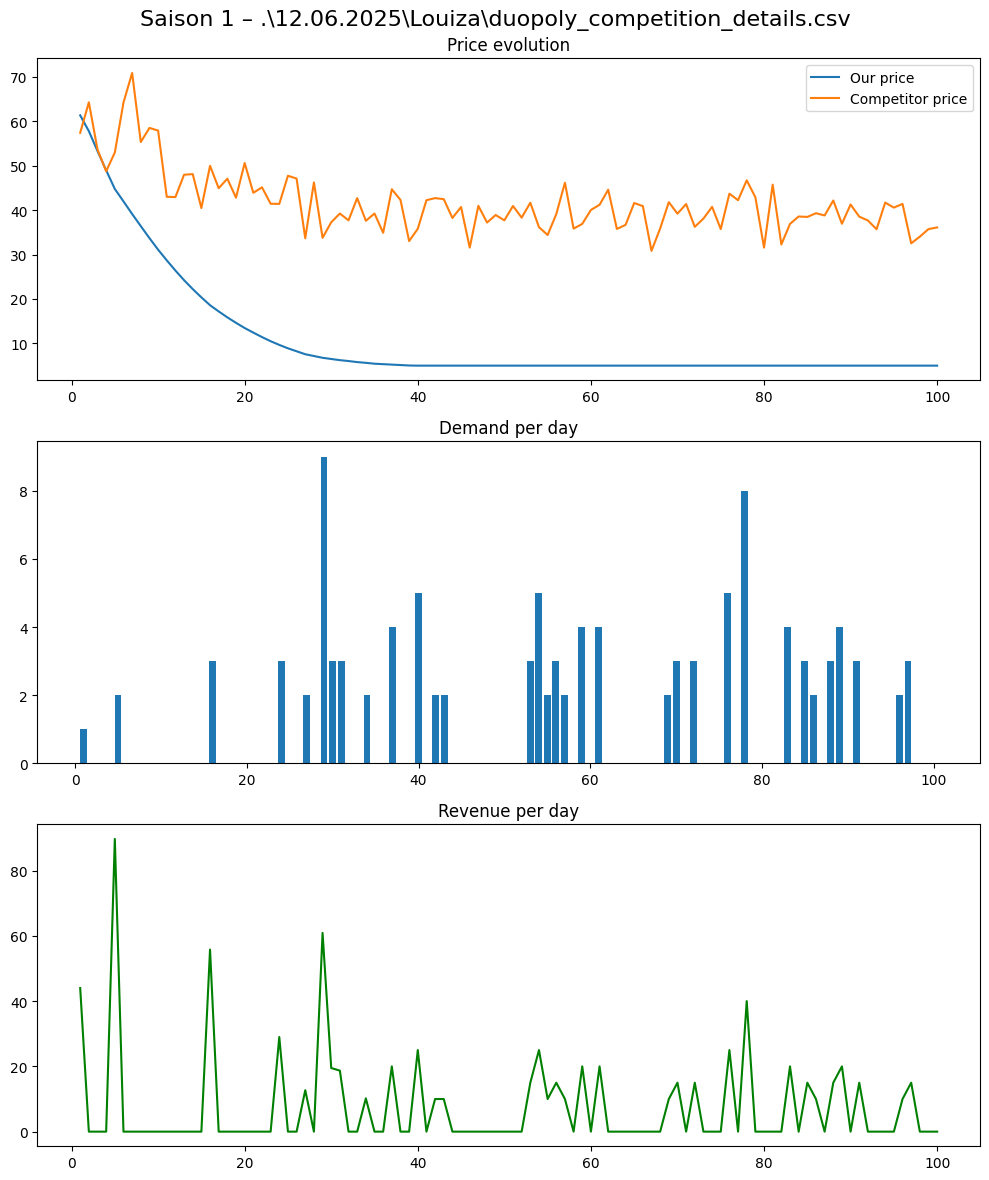

In [ ]:
import matplotlib.pyplot as plt

def plot_season(agg, title=""):
    fig, axes = plt.subplots(3, 1, figsize=(10,12))

    axes[0].plot(agg["day"], agg["our_price"], label="Our price")
    axes[0].plot(agg["day"], agg["competitor_price"], label="Competitor price")
    axes[0].set_title("Price evolution")
    axes[0].legend()

    axes[1].bar(agg["day"], agg["our_demand"])
    axes[1].set_title("Demand per day")

    axes[2].plot(agg["day"], agg["revenue"], color="green")
    axes[2].set_title("Revenue per day")

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


# Exemple :
plot_season(
    aggregate_by_day(first_season),
    title=f"Saison 1 – {first_path}"
)


<Axes: title={'center': 'Revenue per season'}, xlabel='season'>

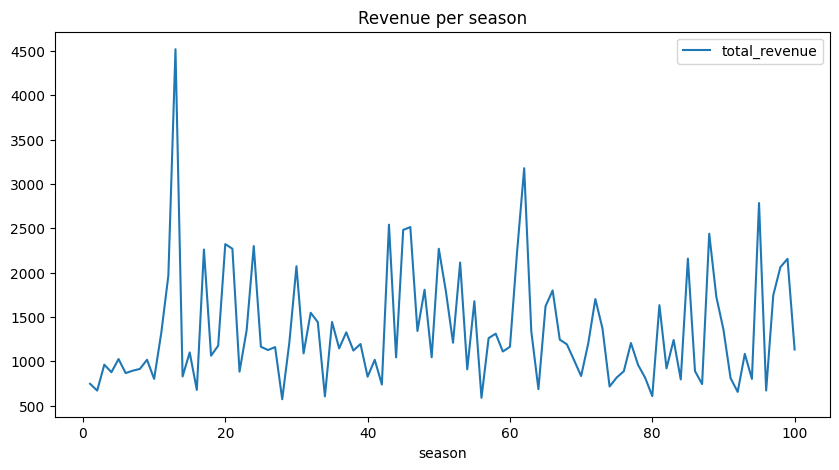

In [ ]:
global_kpis[first_path][["season","total_revenue"]].plot(
    x="season", y="total_revenue", figsize=(10,5), title="Revenue per season"
)


In [ ]:
import matplotlib.pyplot as plt

def plot_cumulative_revenue(season_df, title=""):
    plt.style.use("ggplot")

    # revenu cumulé
    cumrev = season_df["revenue"].cumsum()

    plt.figure(figsize=(10,5))
    plt.plot(season_df["day"], cumrev, 'k', linewidth=3)
    plt.xlabel("Jour")
    plt.ylabel("Revenu cumulé")
    plt.title(title)
    plt.tight_layout()
    plt.show()


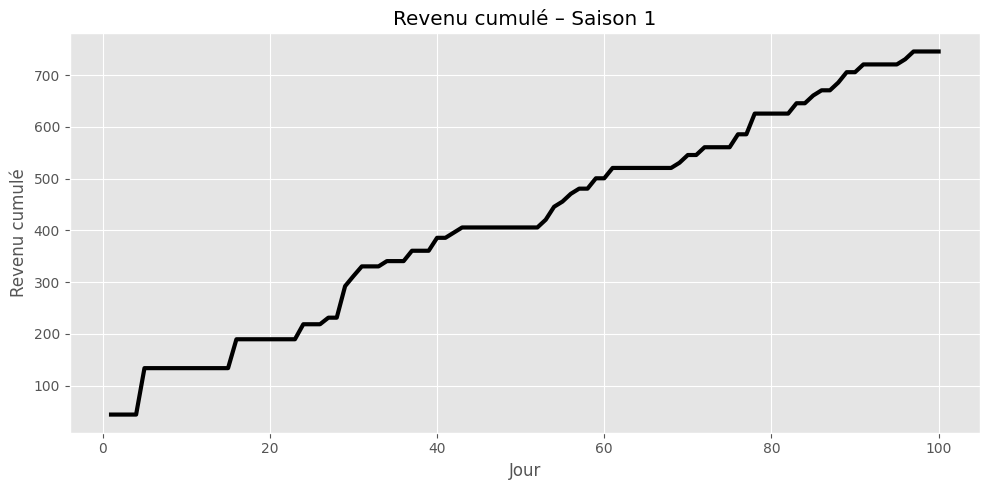

In [ ]:
first_season_agg = aggregate_by_day(first_season)
plot_cumulative_revenue(first_season_agg, "Revenu cumulé – Saison 1")


In [ ]:
import matplotlib.pyplot as plt

def plot_cumulative_revenue_all_seasons(seasons_dict, title=""):
    plt.style.use("ggplot")
    plt.figure(figsize=(12,6))

    for season_id, season_df in seasons_dict.items():
        agg = season_df.groupby("day")["revenue"].sum().reset_index()
        cumrev = agg["revenue"].cumsum()
        plt.plot(agg["day"], cumrev, alpha=0.2, color="black")  # fin et transparent

    plt.title(title)
    plt.xlabel("Jour")
    plt.ylabel("Revenu cumulé")
    plt.tight_layout()
    plt.show()


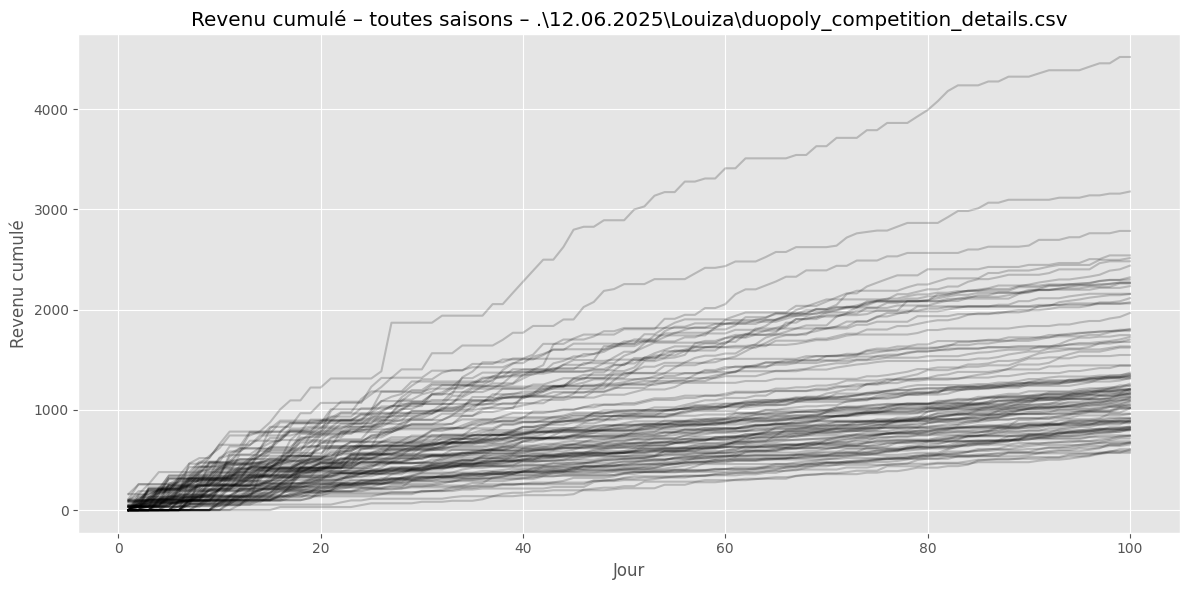

In [ ]:
plot_cumulative_revenue_all_seasons(
    all_seasons[first_path],
    title=f"Revenu cumulé – toutes saisons – {first_path}"
)


In [ ]:
def plot_avg_cumulative_revenue(seasons_dict, title=""):
    plt.style.use("ggplot")
    plt.figure(figsize=(12,5))

    all_cumrev = []

    for season_id, season_df in seasons_dict.items():
        agg = season_df.groupby("day")["revenue"].sum().reset_index()
        cumrev = agg["revenue"].cumsum()
        all_cumrev.append(cumrev.values)

    avg_cumrev = np.mean(all_cumrev, axis=0)
    plt.plot(range(1, len(avg_cumrev)+1), avg_cumrev, "k", linewidth=3)

    plt.title(title)
    plt.xlabel("Jour")
    plt.ylabel("Revenu cumulé moyen")
    plt.tight_layout()
    plt.show()


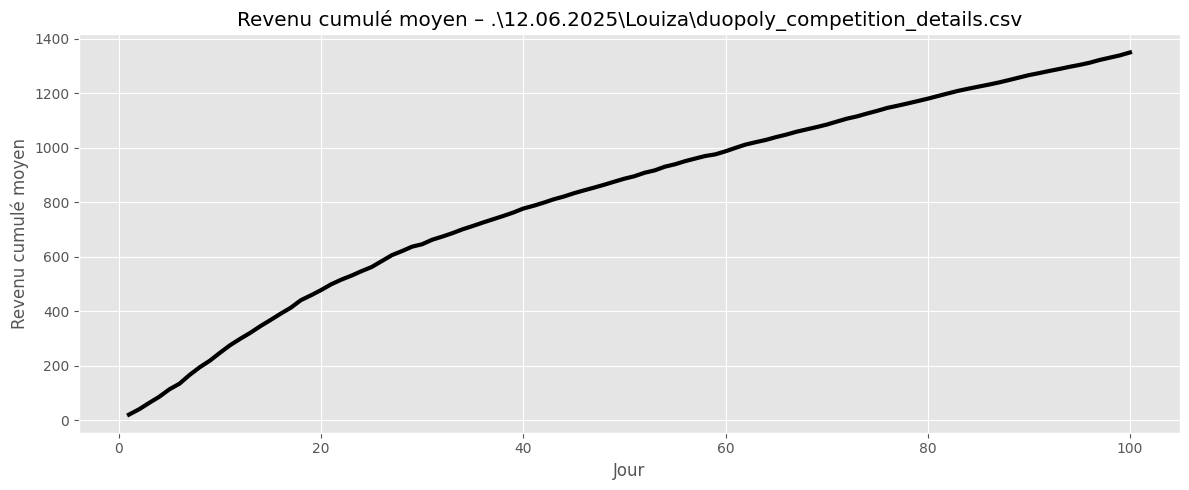

In [ ]:
plot_avg_cumulative_revenue(
    all_seasons[first_path],
    title=f"Revenu cumulé moyen – {first_path}"
)


CSV trouvés : 9
 - .\06.12.2025\Louiza\duopoly_competition_details.csv
 - .\08.12.2025\Louiza\duopoly_competition_details.csv
 - .\15.11.2025\Louiza\duopoly_competition_details.csv
 - .\15.11.2025\Quentin\duopoly_competition_details.csv
 - .\17.11.2025\Louiza\duopoly_competition_details.csv
 - .\17.11.2025\Quentin\duopoly_competition_details.csv
 - .\19.11.2025\Quentin\duopoly_competition_details.csv
 - .\22.11.2025\Quentin\duopoly_competition_details.csv
 - .\24.11.2025\Quentin\duopoly_competition_details.csv
✔ Chargé : .\06.12.2025\Louiza\duopoly_competition_details.csv → 30000 lignes
✔ Chargé : .\08.12.2025\Louiza\duopoly_competition_details.csv → 20000 lignes
✔ Chargé : .\15.11.2025\Louiza\duopoly_competition_details.csv → 40000 lignes
✔ Chargé : .\15.11.2025\Quentin\duopoly_competition_details.csv → 40000 lignes
✔ Chargé : .\17.11.2025\Louiza\duopoly_competition_details.csv → 40000 lignes
✔ Chargé : .\17.11.2025\Quentin\duopoly_competition_details.csv → 40000 lignes
✔ Chargé : .\1

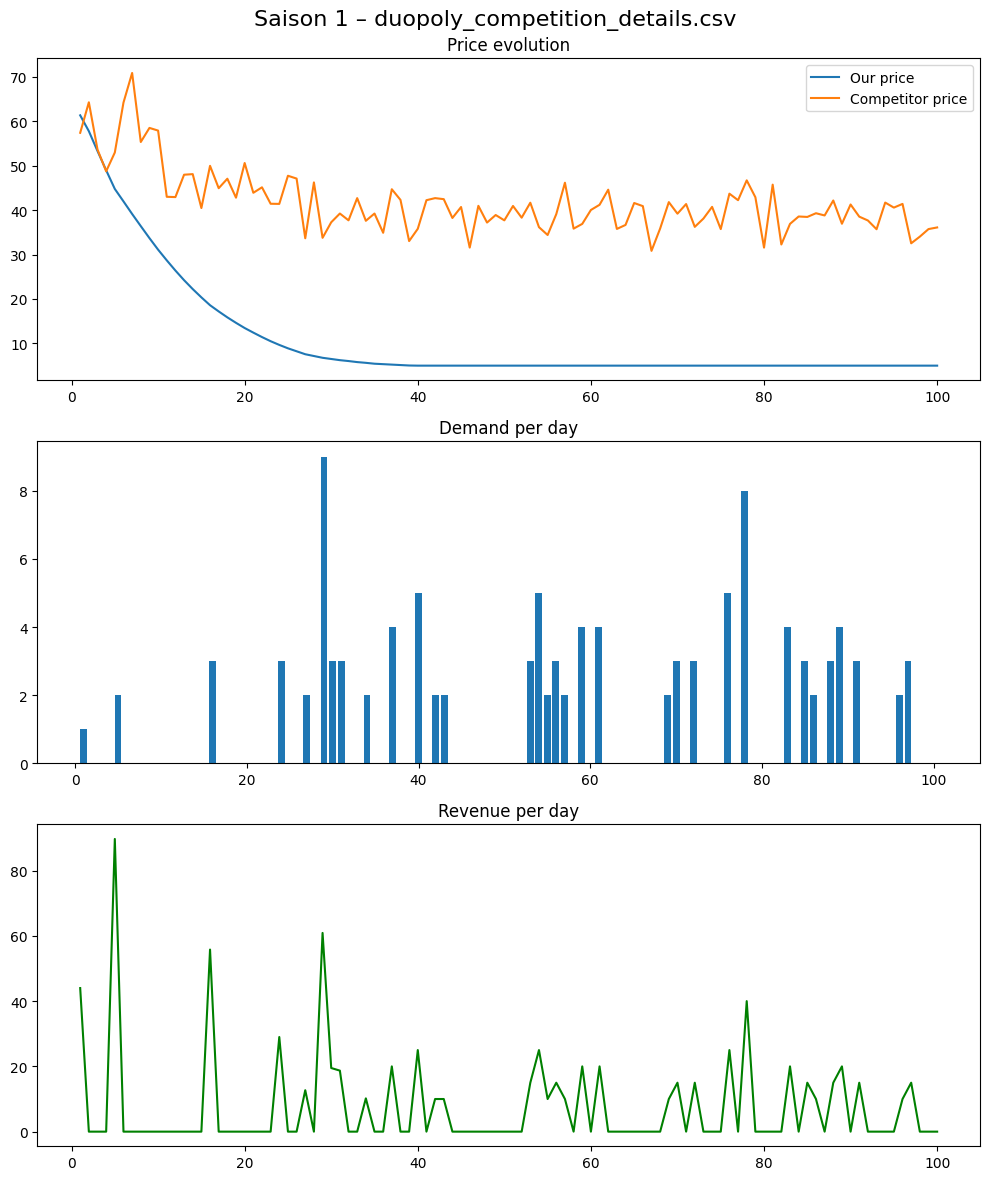

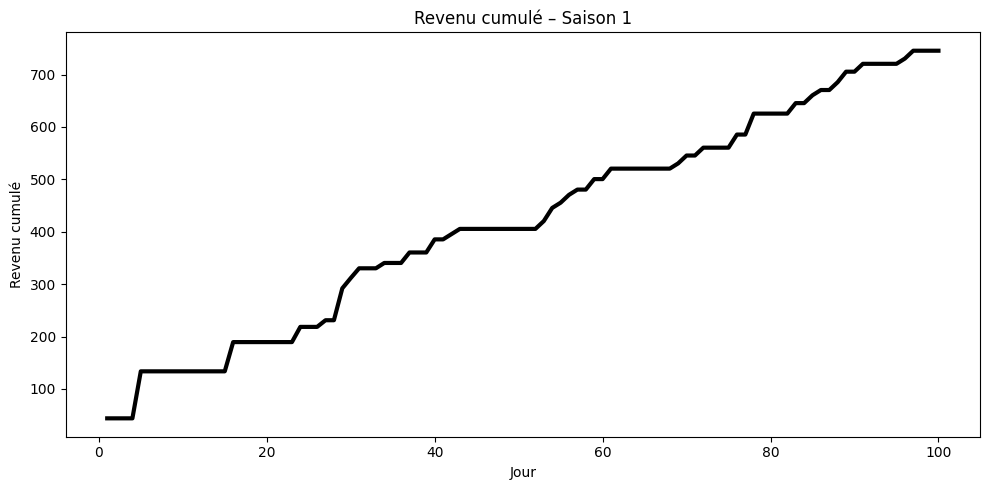

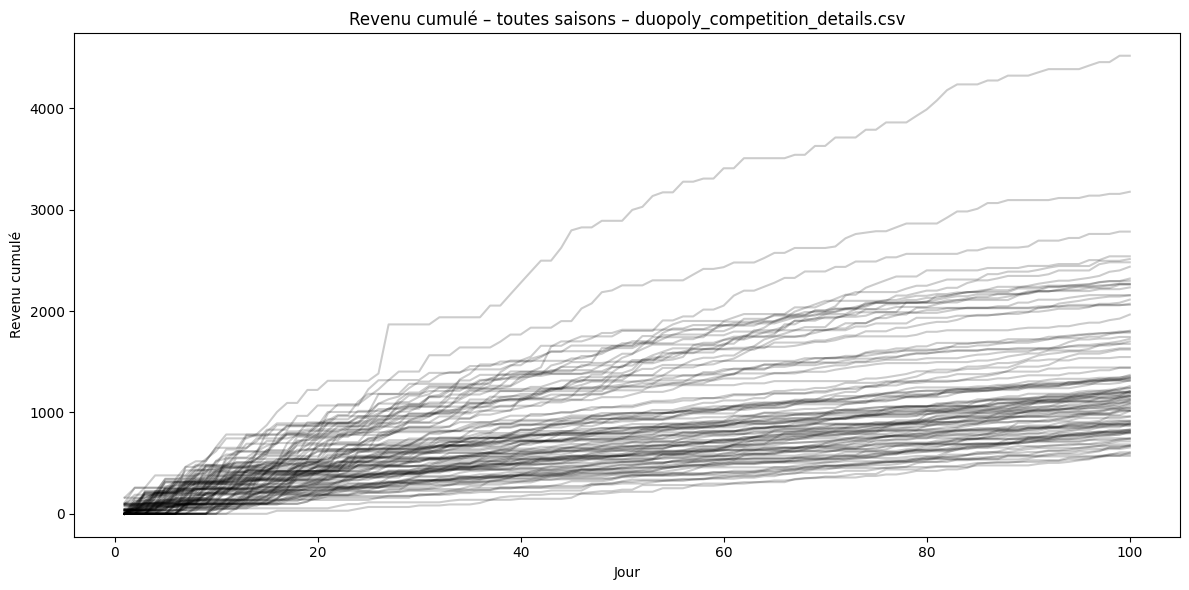

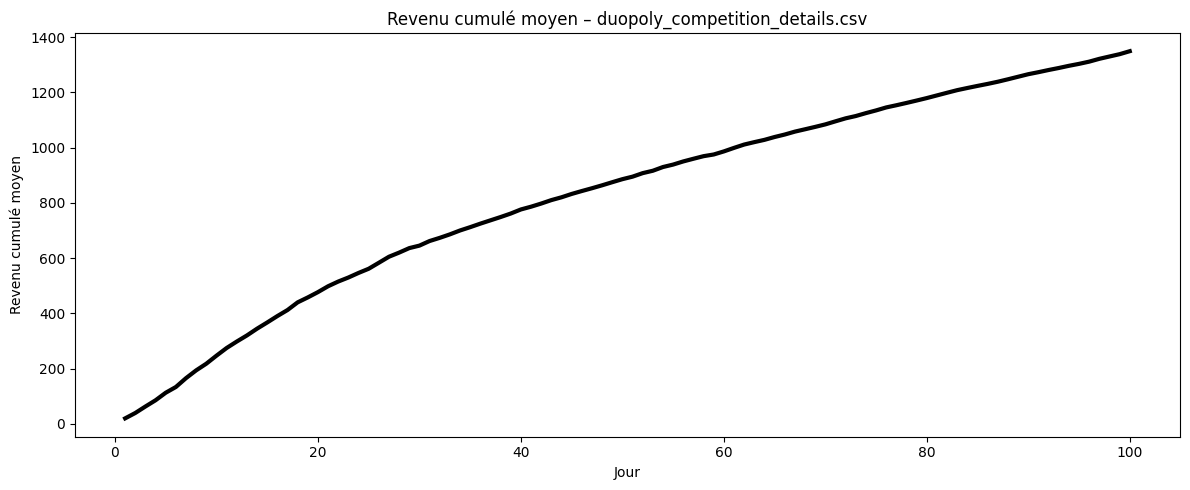

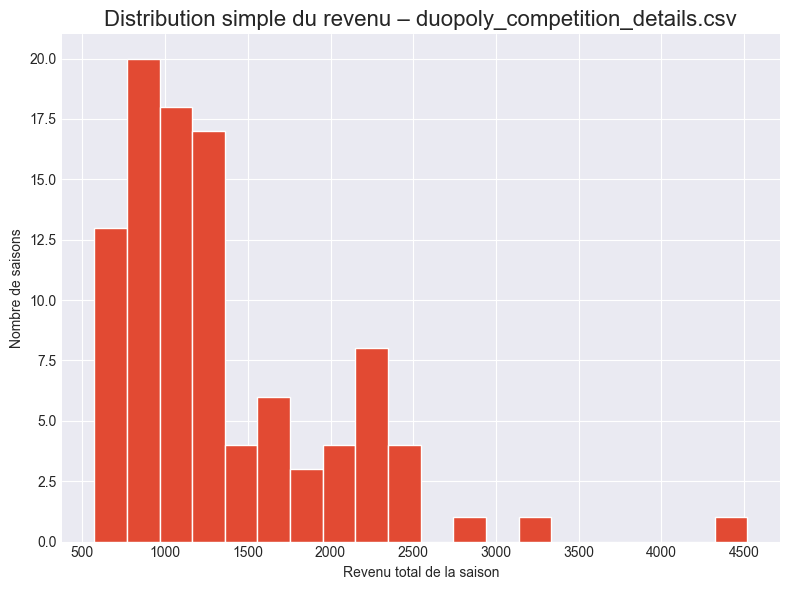

In [2]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1) CHARGEMENT DE TOUS LES CSV
# ============================================================

base_path = "."
all_csv_paths = []

for root, dirs, files in os.walk(base_path):

    # On ignore le dossier Analyse
    if "Analyse" in root:
        continue

    for file in files:
        if file.endswith(".csv"):
            all_csv_paths.append(os.path.join(root, file))

print("CSV trouvés :", len(all_csv_paths))
for p in all_csv_paths:
    print(" -", p)


# ============================================================
# 2) FONCTION DE NORMALISATION DES CSV
# ============================================================

def load_and_prepare(path):
    df = pd.read_csv(path)

    df = df.rename(columns={
        "selling_period": "day",
        "price": "our_price",
        "price_competitor": "competitor_price",
        "demand": "our_demand"
    })

    if "day" not in df.columns:
        df["day"] = df["selling_season"]  # fallback improbable mais safe

    df["revenue"] = df["our_price"] * df["our_demand"]
    df["cum_revenue"] = df["revenue"].cumsum()

    return df


# ============================================================
# 3) CHARGEMENT DE TOUS LES CSV
# ============================================================

all_results = {}
for path in all_csv_paths:
    df = load_and_prepare(path)
    all_results[path] = df
    print("✔ Chargé :", path, "→", len(df), "lignes")


# ============================================================
# 4) SPLIT EN SAISONS
# ============================================================

def split_into_seasons(df):
    seasons = {}
    for season_id, season_df in df.groupby("selling_season"):
        seasons[int(season_id)] = season_df.reset_index(drop=True)
    return seasons


all_seasons = {}

for path, df in all_results.items():
    all_seasons[path] = split_into_seasons(df)
    print(path, "→", len(all_seasons[path]), "saisons trouvées")


# ============================================================
# 5) AGRÉGATION PAR JOUR
# ============================================================

def aggregate_by_day(season_df):
    return season_df.groupby("day").agg({
        "our_price": "mean",
        "competitor_price": "mean",
        "our_demand": "sum",
        "revenue": "sum"
    }).reset_index()


# Exemple : sélection du premier CSV + saison 1
first_path = list(all_seasons.keys())[0]
first_season = all_seasons[first_path][1]
first_season_agg = aggregate_by_day(first_season)


# ============================================================
# 6) KPI PAR SAISON
# ============================================================

def season_kpis(agg):
    return {
        "total_revenue": agg["revenue"].sum(),
        "mean_price": agg["our_price"].mean(),
        "mean_demand": agg["our_demand"].mean(),
        "corr_price_demand": agg["our_price"].corr(agg["our_demand"]),
        "corr_competitor_demand": agg["competitor_price"].corr(agg["our_demand"])
    }


# KPIs globaux
global_kpis = {}

for path, seasons in all_seasons.items():
    results = []
    for sid, sdf in seasons.items():
        agg = aggregate_by_day(sdf)
        kpi = season_kpis(agg)
        kpi["season"] = sid
        results.append(kpi)

    global_kpis[path] = pd.DataFrame(results)
    print("✔ KPIs calculés pour :", path)


# Sélection du jeu principal
kpis_first = global_kpis[first_path]


# ============================================================
# 7) FONCTIONS DE VISUALISATION
# ============================================================

# --- Graphique 1 : Évolution prix / demande / revenu (saison)
def plot_season(agg, title=""):
    fig, axes = plt.subplots(3, 1, figsize=(10,12))

    axes[0].plot(agg["day"], agg["our_price"], label="Our price")
    axes[0].plot(agg["day"], agg["competitor_price"], label="Competitor price")
    axes[0].set_title("Price evolution")
    axes[0].legend()

    axes[1].bar(agg["day"], agg["our_demand"])
    axes[1].set_title("Demand per day")

    axes[2].plot(agg["day"], agg["revenue"], color="green")
    axes[2].set_title("Revenue per day")

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


# --- Graphique 2 : Revenu cumulé d'une saison
def plot_cumulative_revenue(season_agg, title=""):
    cumrev = season_agg["revenue"].cumsum()
    plt.figure(figsize=(10,5))
    plt.plot(season_agg["day"], cumrev, 'k', linewidth=3)
    plt.xlabel("Jour")
    plt.ylabel("Revenu cumulé")
    plt.title(title)
    plt.tight_layout()
    plt.show()


# --- Graphique 3 : Revenus cumulés de toutes les saisons d'un fichier
def plot_cumulative_revenue_all_seasons(seasons_dict, title=""):
    plt.figure(figsize=(12,6))
    for season_id, season_df in seasons_dict.items():
        agg = season_df.groupby("day")["revenue"].sum().reset_index()
        cumrev = agg["revenue"].cumsum()
        plt.plot(agg["day"], cumrev, alpha=0.2, color="black")

    plt.title(title)
    plt.xlabel("Jour")
    plt.ylabel("Revenu cumulé")
    plt.tight_layout()
    plt.show()


# --- Graphique 4 : Revenu cumulé moyen
def plot_avg_cumulative_revenue(seasons_dict, title=""):
    plt.figure(figsize=(12,5))
    all_cumrev = []

    for season_id, season_df in seasons_dict.items():
        agg = season_df.groupby("day")["revenue"].sum().reset_index()
        cumrev = agg["revenue"].cumsum()
        all_cumrev.append(cumrev.values)

    avg_cumrev = np.mean(all_cumrev, axis=0)
    plt.plot(range(1, len(avg_cumrev)+1), avg_cumrev, "k", linewidth=3)

    plt.title(title)
    plt.xlabel("Jour")
    plt.ylabel("Revenu cumulé moyen")
    plt.tight_layout()
    plt.show()


# --- Graphique 5 (NOUVEAU) : Histogramme simple type "clean"
def plot_simple_revenue_hist(kpis_df, title="Distribution simple du revenu"):
    plt.style.use("seaborn-v0_8-darkgrid")
    plt.figure(figsize=(8,6))

    plt.hist(
        kpis_df["total_revenue"],
        bins=20,
        color="#E24A33",
        edgecolor="white"
    )

    plt.title(title, fontsize=16)
    plt.xlabel("Revenu total de la saison")
    plt.ylabel("Nombre de saisons")
    plt.tight_layout()
    plt.show()


# ============================================================
# 8) AFFICHAGE DES GRAPHIQUES
# ============================================================

plot_season(first_season_agg, title=f"Saison 1 – {os.path.basename(first_path)}")

plot_cumulative_revenue(first_season_agg, "Revenu cumulé – Saison 1")

plot_cumulative_revenue_all_seasons(
    all_seasons[first_path],
    title=f"Revenu cumulé – toutes saisons – {os.path.basename(first_path)}"
)

plot_avg_cumulative_revenue(
    all_seasons[first_path],
    title=f"Revenu cumulé moyen – {os.path.basename(first_path)}"
)

plot_simple_revenue_hist(
    kpis_first,
    title=f"Distribution simple du revenu – {os.path.basename(first_path)}"
)
